In [163]:
# Helper functions
from PIL import Image
import numpy as np
from numpy import uint8
import matplotlib.pyplot as plt

def read_image(rgbImage: Image.Image):
    rgb = np.asarray(Image.open(rgbImage).convert("RGB"), dtype=np.float64) / 255.0
    return rgb

def rgb_to_gray(rgb):
    return 0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]

def display_rgb_image(rgb):
    plt.imshow(rgb); plt.axis("off"); plt.show()

def display_gray_image(gray):
    plt.imshow(gray, cmap="gray", vmin=0, vmax=1); plt.axis("off"); plt.show()

def build_histogram(gray01, n_bins=256):
    u8 = to_uint8(gray01)
    counts = np.bincount(u8.ravel(), minlength=n_bins).astype(np.float64)
    return np.arange(n_bins), counts

from numpy import uint8
def to_uint8(gray01):
    return np.clip(np.round(gray01 * 255), 0, 255).astype(uint8)

def show_histogram(gray01, title="Histogram", color="lightcoral"):
    bins, counts = build_histogram(gray01)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(bins, counts, width=1.0, color=color, edgecolor="none")
    ax.set_xlim(0, 255)
    ax.set_xlabel("Gray level r")
    ax.set_ylabel("count nᵣ")                   
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()

Question 1: Reading and manipulating images.

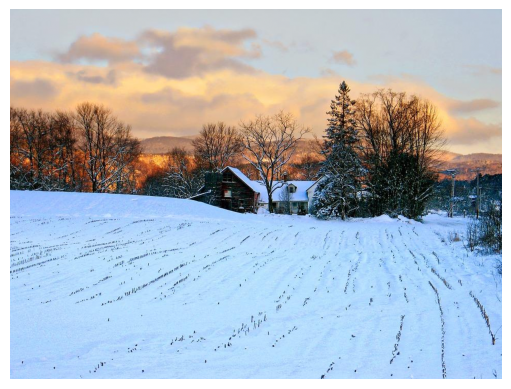

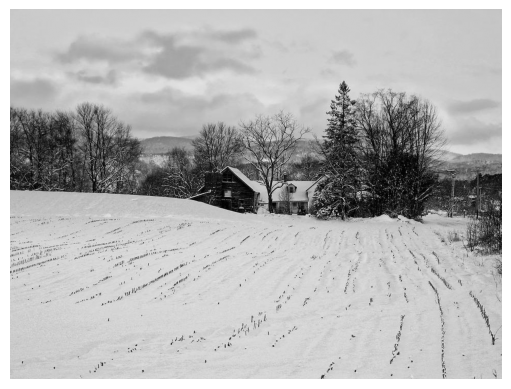

In [164]:
# 1(a) Read Winter.png, display in color, display in grayscale
winterRgb = read_image("Winter.png")
winterGray = rgb_to_gray(winterRgb)
display_rgb_image(winterRgb)
display_gray_image(winterGray)

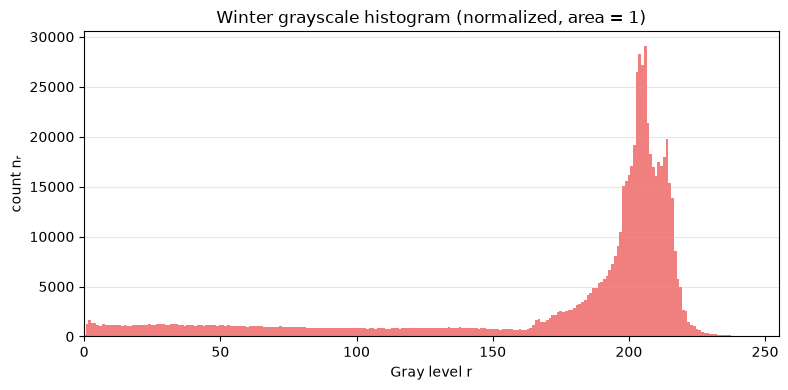

In [165]:
# 1(b) Plot the black and white histogram and normalize so that the area under the
# histogram is equal to one.    
show_histogram(winterGray, title="Winter grayscale histogram (normalized, area = 1)")

1(c) Crop any region of 100-by-100 pixels where there is snow on the ground, display, and plot its histogram

I cropped a patch on the open snow field (row 400, col 200).

In [166]:
print(winterGray.shape)

(719, 957)


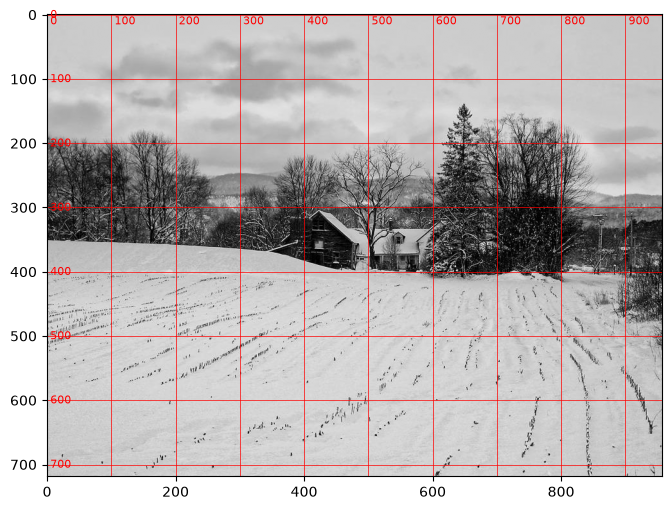

In [167]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(winterGray, cmap="gray", vmin=0, vmax=1)
H, W = winterGray.shape
for r in range(0, H, 100):
    ax.axhline(r, color="red", lw=0.5)
    ax.text(5, r+5, str(r), color="red", fontsize=8)
for c in range(0, W, 100):
    ax.axvline(c, color="red", lw=0.5)
    ax.text(c+5, 15, str(c), color="red", fontsize=8)
plt.show()

In [168]:
r0, c0 = 400, 200          # top-left corner of the crop (adjust as you like)
h, w   = 100, 100

snow_patch = winterGray[r0:r0+h, c0:c0+w]   # float, [0, 1]

print("patch:", snow_patch.shape, snow_patch.dtype,
      "range:", snow_patch.min(), snow_patch.max())

patch: (100, 100) float64 range: 0.032141176470588236 0.9659960784313725


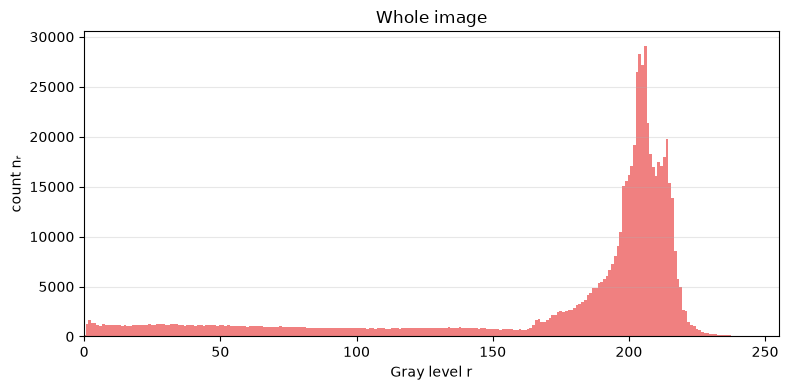

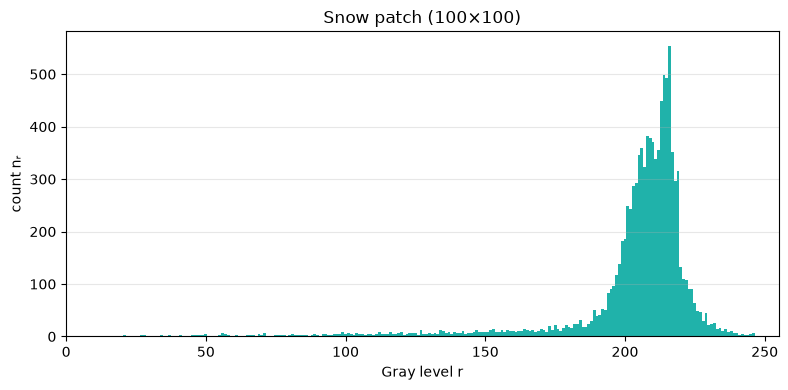

full: 0.0 0.9953960784313726
patch: 0.032141176470588236 0.9659960784313725


In [169]:
# show image and histogram of the patch
show_histogram(winterGray, title="Whole image")
show_histogram(snow_patch, title=f"Snow patch ({h}×{w})", color="lightseagreen")

print("full:", winterGray.min(), winterGray.max())
print("patch:", snow_patch.min(), snow_patch.max())

Compare the histograms of the entire image and the subregion by overlaying on
top of each other!

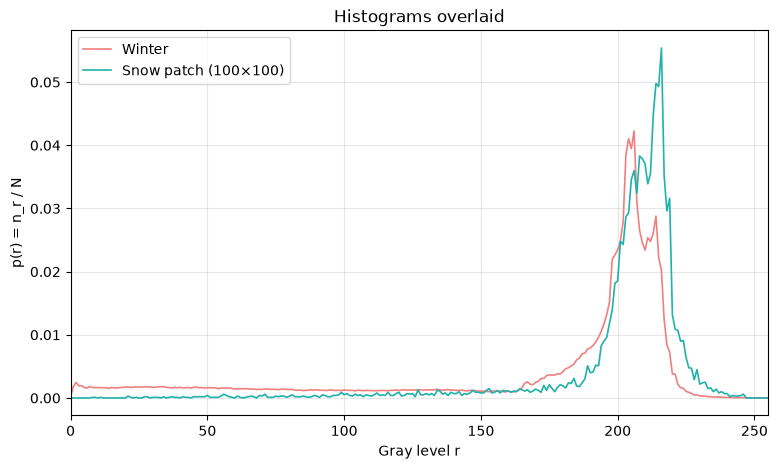

In [170]:
def overlay_histograms(gray1, gray2, label1="Image 1", label2="Image 2"):
    bins, pmf1, _ = histogram_pmf(gray1)
    _, pmf2, _ = histogram_pmf(gray2)
    
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(bins, pmf1, color="lightcoral", lw=1.2, label=label1)
    ax.plot(bins, pmf2, color="lightseagreen",   lw=1.2, label=label2)
    ax.set_xlim(0, 255)
    ax.set_xlabel("Gray level r")
    ax.set_ylabel("p(r) = n_r / N")
    ax.set_title("Histograms overlaid")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

overlay_histograms(winterGray, snow_patch, label1="Winter", label2=f"Snow patch ({h}×{w})")

1e. Read Desert.png, convert to a black and white image, and display.

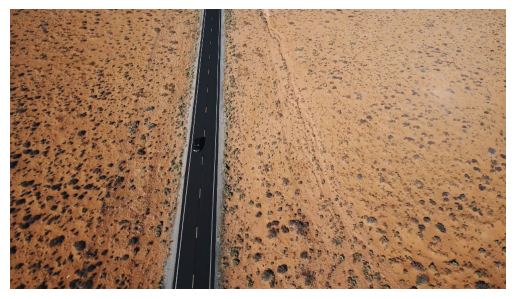

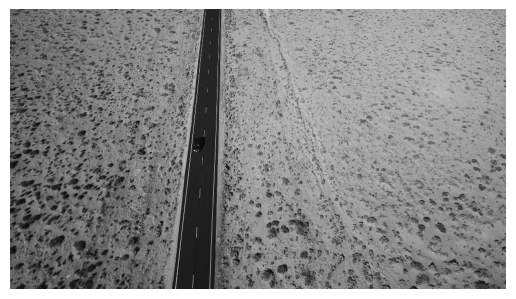

In [171]:
desertRgb = read_image("Desert.png")
desertGray = rgb_to_gray(desertRgb)
display_rgb_image(desertRgb)
display_gray_image(desertGray)

Compare the histograms of (e) and (b) by overlaying them. Can these two
images be discriminated by their histogram?

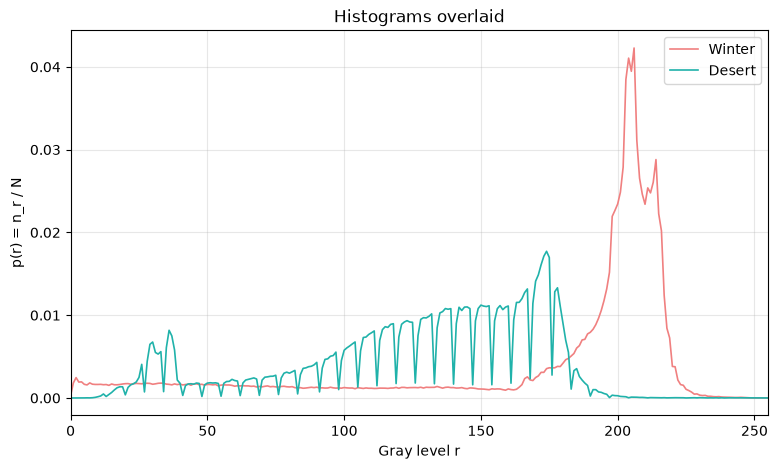

In [172]:
overlay_histograms(winterGray, desertGray, label1="Winter", label2="Desert")

Question 2: Use the “Buildings” Image to (i) convert color to gray scale, (ii) downsample the image (comments on the results) by three-levels to build a pyramid representation.

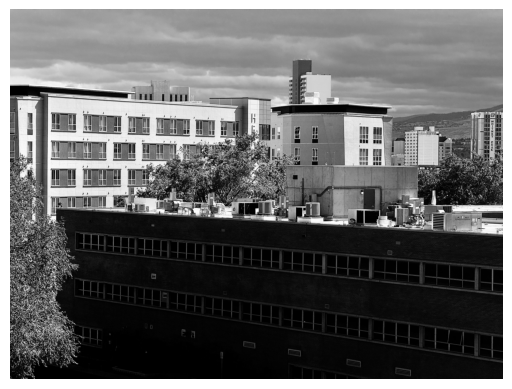

In [173]:
buildingsRgb = read_image("Buildings.jpeg")
buildingsGray = rgb_to_gray(buildingsRgb)
display_gray_image(buildingsGray)

In [174]:
# Gaussian filters
def gaussian_kernel_1d(sigma, truncate=4.0):
    r = int(truncate*sigma + 0.5)
    x = np.arange(-r, r+1)
    k = np.exp(-(x**2)/(2*sigma**2))
    return k / k.sum()

def _conv1d_same(a, k, axis, mode="reflect"):
    r = len(k)//2
    pad = [(0,0)]*a.ndim
    pad[axis] = (r, r)
    ap = np.pad(a, pad, mode=mode)
    ap = np.moveaxis(ap, axis, 0)
    out = np.zeros_like(np.moveaxis(a, axis, 0), dtype=np.float64)
    for i, w in enumerate(k):
        out += w * ap[i : i + out.shape[0]]
    return np.moveaxis(out, 0, axis)

def gaussian_filter_np(img, sigma, truncate=4.0, mode="reflect"):
    k = gaussian_kernel_1d(sigma, truncate)
    out = _conv1d_same(img, k, axis=0, mode=mode)
    out = _conv1d_same(out, k, axis=1, mode=mode)
    return out

In [175]:
# Pyramid
def gaussian_pyramid(gray, levels=4, sigma=1.0):
    """Returns [level0, level1, ..., level_{levels-1}].
       level0 = original, level_{n+1} = downsample(blur(level_n))."""
    pyr = [gray]
    cur = gray
    for _ in range(levels - 1):
        blurred = gaussian_filter_np(cur, sigma=sigma, mode="reflect")
        # downsample by 2 — take every other row/col
        cur = blurred[::2, ::2]
        pyr.append(cur)
    return pyr

pyr = gaussian_pyramid(buildingsGray, levels=4, sigma=1.0)
for i, lvl in enumerate(pyr):
    print(f"level {i}: shape {lvl.shape}, mean {lvl.mean():.3f}")

level 0: shape (3024, 4032), mean 0.345
level 1: shape (1512, 2016), mean 0.345
level 2: shape (756, 1008), mean 0.345
level 3: shape (378, 504), mean 0.346


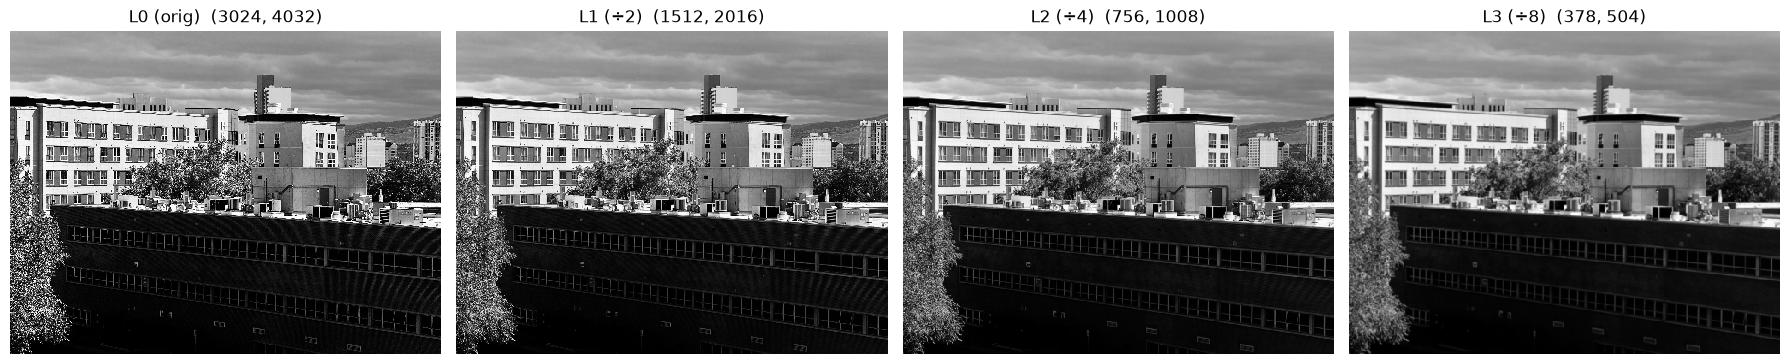

In [176]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, lvl, name in zip(axes, pyr, ["L0 (orig)", "L1 (÷2)", "L2 (÷4)", "L3 (÷8)"]):
    ax.imshow(lvl, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(f"{name}  {lvl.shape}")
    ax.axis("off")
fig.tight_layout(); plt.show()

Question 3: 
Use the valley, apply image enhancement, and show the histogram before and after
histogram equalization.

In [177]:
valley_gray = rgb_to_gray(read_image("Valley.tif"))

def histogram_equalize(gray01, n_bins=256):
    # CDF-based histogram equalization. Input/output in [0,1].
    u8 = to_uint8(gray01)
    counts = np.bincount(u8.ravel(), minlength=n_bins).astype(np.float64)
    cdf = counts.cumsum()
    cdf_norm = cdf / cdf[-1]                      # in [0,1]
    # build LUT: map old level -> new level
    lut = np.round((n_bins - 1) * cdf_norm).astype(np.uint8)
    eq_u8 = lut[u8]
    return eq_u8.astype(np.float64) / 255.0

valley_eq = histogram_equalize(valley_gray)
valley_eq

array([[0.17254902, 0.51372549, 0.68235294, ..., 0.45882353, 0.43137255,
        0.73333333],
       [0.0745098 , 0.37254902, 0.45882353, ..., 0.56862745, 0.54117647,
        0.68235294],
       [0.13333333, 0.4       , 0.51372549, ..., 0.92941176, 0.92941176,
        0.87843137],
       ...,
       [0.17254902, 0.01568627, 0.10196078, ..., 0.48627451, 0.48627451,
        0.48627451],
       [0.17254902, 0.01568627, 0.10196078, ..., 0.4       , 0.4       ,
        0.43137255],
       [0.17254902, 0.01568627, 0.10196078, ..., 0.37254902, 0.37254902,
        0.4       ]], shape=(248, 381))

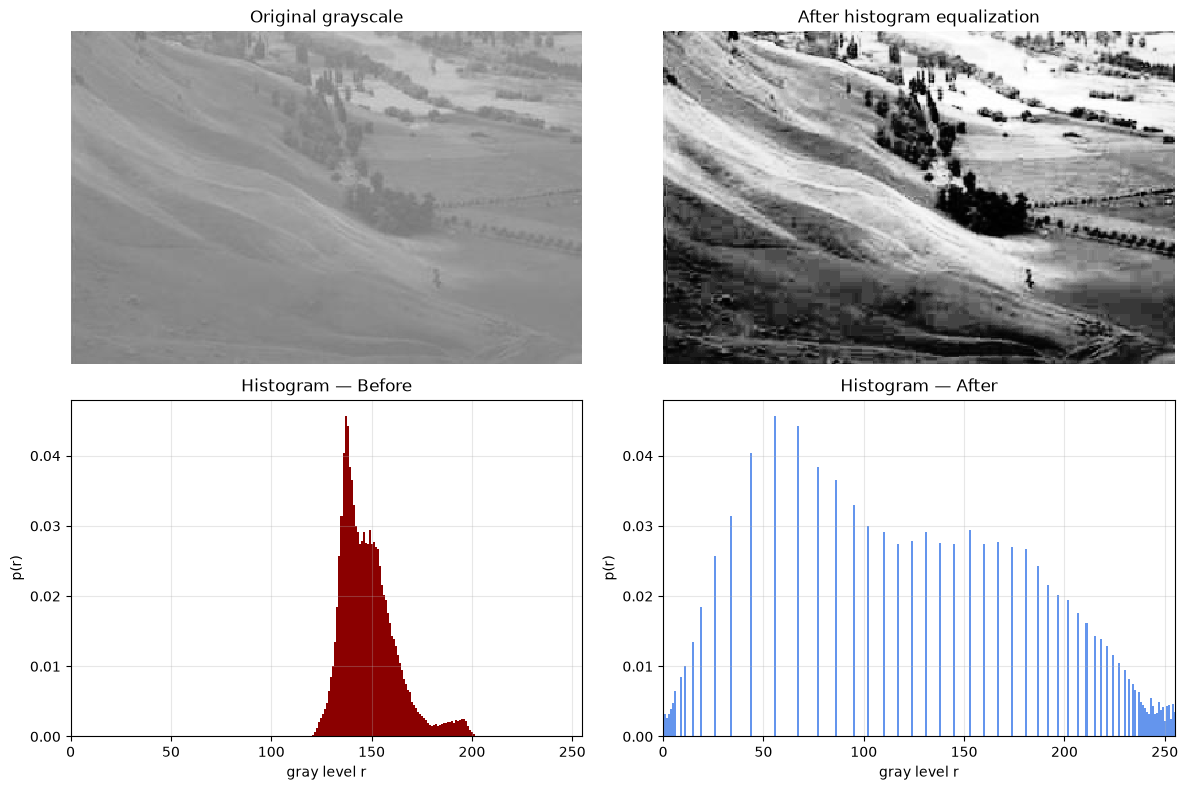

In [178]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].imshow(valley_gray, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
axes[0,0].set_title("Original grayscale"); axes[0,0].axis("off")

axes[0,1].imshow(valley_eq, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
axes[0,1].set_title("After histogram equalization"); axes[0,1].axis("off")

for ax, img, name, col in [(axes[1,0], valley_gray, "Before", "darkred"),
                           (axes[1,1], valley_eq,   "After",  "cornflowerblue")]:
    bins, pmf, _ = histogram_pmf(img)
    ax.bar(bins, pmf, width=1.0, color=col, edgecolor="none")
    ax.set_xlim(0, 255)
    ax.set_xlabel("gray level r"); ax.set_ylabel("p(r)")
    ax.set_title(f"Histogram — {name}")
    ax.grid(alpha=0.3)

fig.tight_layout(); plt.show()

Question 4: 
Use the image called “nature.JPG,” and enhance the image to find something
interesting. Plot the original and revised histograms. Be creative!

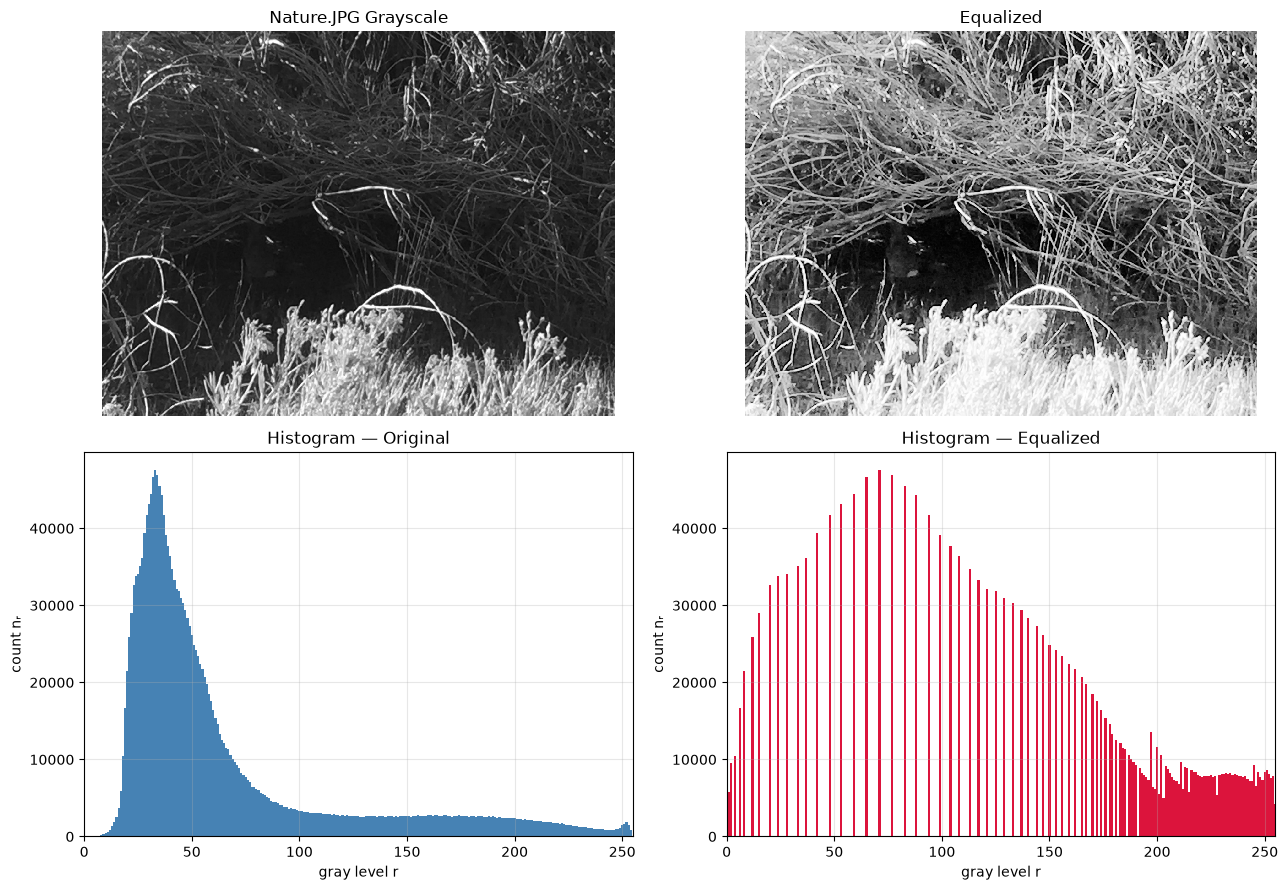

In [179]:
# 1. Load and convert to gray
nature_rgb  = read_image("nature.JPG")
nature_gray = rgb_to_gray(nature_rgb)

# 2. Equalize
nature_eq = histogram_equalize(nature_gray)

# 3. Before / after — image + histogram
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, img, name in [(axes[0,0], nature_gray, "Nature.JPG Grayscale"),
                      (axes[0,1], nature_eq,   "Equalized")]:
    ax.imshow(img, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(name); ax.axis("off")

for ax, img, name, col in [(axes[1,0], nature_gray, "Original",  "steelblue"),
                           (axes[1,1], nature_eq,   "Equalized", "crimson")]:
    bins, counts = build_histogram(img)
    ax.bar(bins, counts, width=1.0, color=col, edgecolor="none")
    ax.set_xlim(0, 255)
    ax.set_xlabel("gray level r"); ax.set_ylabel("count nᵣ")
    ax.set_title(f"Histogram — {name}")
    ax.grid(alpha=0.3)

fig.tight_layout(); plt.show()